# Module 5 — IPL Analysis Dashboard
**Unit V — Information Visualization | IPL 2008–2019**

This dashboard summarizes the most important insights from all four analysis modules
into a single view. Each panel answers one real cricket question.

**Layout — 2 rows × 3 columns:**
```
[ Batting Trend      ] [ Phase Run Rate     ] [ Top 10 Batsmen    ]
[ Bowler Scatter     ] [ Powerplay → Win %  ] [ Venue Impact      ]
```

## Step 1 — Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

print('Libraries loaded')

Libraries loaded


## Step 2 — Load Clean Data

In [2]:
deliveries   = pd.read_csv('deliveries_clean.csv')
legal        = pd.read_csv('legal_deliveries.csv')
matches      = pd.read_csv('matches_clean.csv')
player_stats = pd.read_csv('player_stats.csv')
bowler_stats = pd.read_csv('bowler_stats.csv')

print('deliveries :', deliveries.shape)
print('legal      :', legal.shape)
print('matches    :', matches.shape)
print('player_stats:', player_stats.shape)
print('bowler_stats:', bowler_stats.shape)

deliveries : (178974, 25)
legal      : (173571, 25)
matches    : (752, 17)
player_stats: (152, 10)
bowler_stats: (240, 7)


## Step 3 — Prepare Data for All 6 Panels

In [3]:
# ── PANEL 1: Season trend (batting first vs chasing) ─────────────────────────
season_scores = deliveries.groupby(['match_id', 'season', 'inning'])['total_runs'].sum().reset_index()
avg_inn1 = season_scores[season_scores['inning'] == 1].groupby('season')['total_runs'].mean().round(1)
avg_inn2 = season_scores[season_scores['inning'] == 2].groupby('season')['total_runs'].mean().round(1)

print('Panel 1 — season range:', avg_inn1.index.min(), 'to', avg_inn1.index.max())

Panel 1 — season range: 2008 to 2019


In [4]:
# ── PANEL 2: Phase run rate (total_runs / legal balls * 6) ───────────────────
phase_total_runs  = deliveries.groupby('phase')['total_runs'].sum()
phase_legal_balls = legal.groupby('phase')['ball'].count()

phase_order = ['Powerplay', 'Middle', 'Death']
phase_rr = {}
for p in phase_order:
    phase_rr[p] = round(phase_total_runs[p] / phase_legal_balls[p] * 6, 2)

print('Panel 2 — run rate by phase:', phase_rr)

Panel 2 — run rate by phase: {'Powerplay': np.float64(7.67), 'Middle': np.float64(7.64), 'Death': np.float64(9.77)}


In [5]:
# ── PANEL 3: Top 10 batsmen (from player_stats) ───────────────────────────────
top10 = player_stats.nlargest(10, 'total_runs').sort_values('total_runs')

print('Panel 3 — top 10 batsmen:')
print(top10[['batsman', 'total_runs', 'strike_rate']].to_string())

Panel 3 — top 10 batsmen:
            batsman  total_runs  strike_rate
41        G Gambhir        4220        124.0
3    AB de Villiers        4403        151.5
116      RV Uthappa        4422        130.8
91         MS Dhoni        4450        138.4
23         CH Gayle        4508        151.8
118        S Dhawan        4604        125.4
28        DA Warner        4722        142.9
112       RG Sharma        4902        130.9
125        SK Raina        5382        137.5
143         V Kohli        5421        131.8


In [6]:
# ── PANEL 4: Bowler scatter with quadrant roles ───────────────────────────────
top60 = bowler_stats.nlargest(60, 'wickets').copy()

eco_median = top60['economy'].median()
wkt_median = top60['wickets'].median()

roles = []
for i in range(len(top60)):
    low_eco  = top60.iloc[i]['economy'] <= eco_median
    high_wkt = top60.iloc[i]['wickets'] >= wkt_median
    if low_eco and high_wkt:
        roles.append('Elite')
    elif not low_eco and high_wkt:
        roles.append('Aggressive')
    elif low_eco and not high_wkt:
        roles.append('Defensive')
    else:
        roles.append('Average')

top60['role'] = roles
print('Panel 4 — bowler roles:', top60['role'].value_counts().to_dict())

Panel 4 — bowler roles: {'Elite': 17, 'Average': 17, 'Aggressive': 13, 'Defensive': 13}


In [7]:
# ── PANEL 5: Powerplay score → win % ─────────────────────────────────────────
# Identify who batted first in each match
bat_first_lookup = deliveries[deliveries['inning'] == 1].groupby('match_id')['batting_team'].first().reset_index()
bat_first_lookup.columns = ['id', 'bat_first_team']
matches_ext = matches.merge(bat_first_lookup, on='id', how='left')
matches_ext['bat_first_won'] = (matches_ext['bat_first_team'] == matches_ext['winner']).astype(int)

pp = deliveries[(deliveries['inning'] == 1) & (deliveries['phase'] == 'Powerplay')]
pp_scores = pp.groupby('match_id')['total_runs'].sum().reset_index()
pp_scores.columns = ['id', 'pp_runs']
pp_merged = pp_scores.merge(matches_ext[['id', 'bat_first_team', 'winner', 'bat_first_won']], on='id')

pp_merged['pp_bin'] = pd.cut(
    pp_merged['pp_runs'],
    bins=[0, 30, 40, 50, 60, 120],
    labels=['<30', '30-40', '40-50', '50-60', '>60']
)
win_rate = pp_merged.groupby('pp_bin', observed=True)['bat_first_won'].mean().mul(100).round(1)

print('Panel 5 — powerplay win rate:', win_rate.to_dict())

Panel 5 — powerplay win rate: {'<30': 24.4, '30-40': 39.2, '40-50': 45.4, '50-60': 51.8, '>60': 60.9}


In [8]:
# ── PANEL 6: Venue batting first win % ───────────────────────────────────────
venue_stats = matches_ext.groupby('venue').agg(
    n_matches = ('id', 'count'),
    bat_wins  = ('bat_first_won', 'sum')
).reset_index()
venue_stats['bat_first_pct'] = (venue_stats['bat_wins'] / venue_stats['n_matches'] * 100).round(1)
venue_stats = venue_stats[venue_stats['n_matches'] >= 15].sort_values('bat_first_pct')

name_map = {
    'Rajiv Gandhi International Stadium, Uppal' : 'RGIS Hyderabad',
    'Punjab Cricket Association Stadium, Mohali': 'PCA Mohali',
    'MA Chidambaram Stadium, Chepauk'           : 'Chepauk Chennai',
    'Maharashtra Cricket Association Stadium'   : 'MCA Pune',
    'Dr DY Patil Sports Academy'                : 'DY Patil Mumbai',
    'Subrata Roy Sahara Stadium'                : 'Sahara Pune'
}
venue_stats['venue_short'] = venue_stats['venue'].replace(name_map)

print('Panel 6 — venues:', venue_stats['venue_short'].tolist())

Panel 6 — venues: ['Sawai Mansingh Stadium', 'MCA Pune', 'Eden Gardens', 'RGIS Hyderabad', 'DY Patil Mumbai', 'M Chinnaswamy Stadium', 'PCA Mohali', 'Feroz Shah Kotla', 'Wankhede Stadium', 'Kingsmead', 'Chepauk Chennai', 'Sahara Pune']


## Step 4 — Build the Dashboard

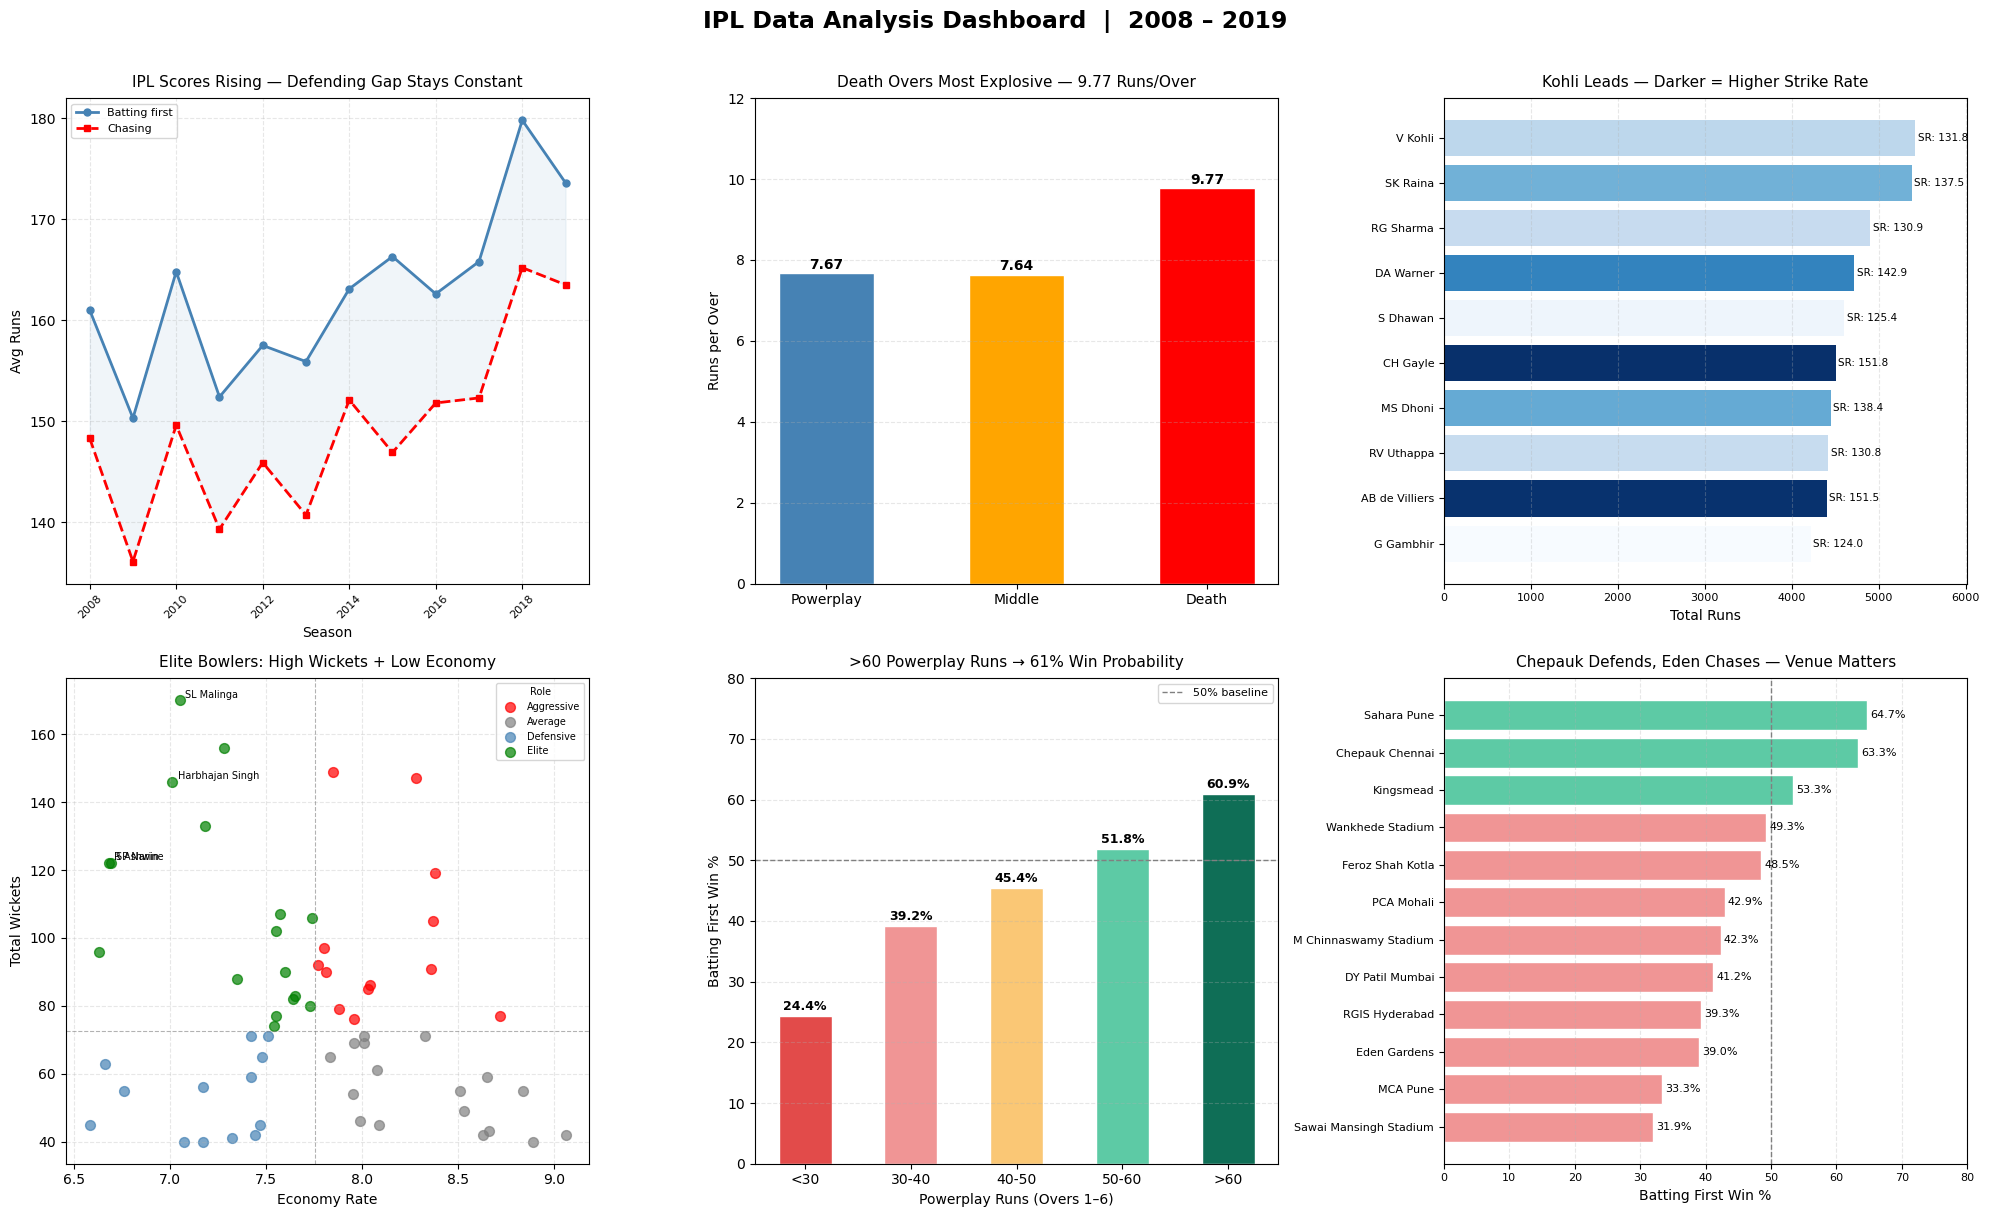

Dashboard saved as dashboard_ipl.png


In [9]:
fig, axes = plt.subplots(2, 3, figsize=(20, 12))
fig.suptitle('IPL Data Analysis Dashboard  |  2008 – 2019',
             fontsize=17, fontweight='bold', y=1.01)

# ─────────────────────────────────────────────────────────────────────────────
# PANEL 1 — Batting Trend: 1st vs 2nd Innings Average
# ─────────────────────────────────────────────────────────────────────────────
ax1 = axes[0, 0]
ax1.plot(avg_inn1.index, avg_inn1.values, color='steelblue', linewidth=2,
         marker='o', markersize=5, label='Batting first')
ax1.plot(avg_inn2.index, avg_inn2.values, color='red', linewidth=2,
         marker='s', markersize=5, label='Chasing', linestyle='--')
ax1.fill_between(avg_inn1.index, avg_inn1.values, avg_inn2.values,
                 alpha=0.08, color='steelblue')
ax1.set_title('IPL Scores Rising — Defending Gap Stays Constant', fontsize=11, pad=8)
ax1.set_xlabel('Season')
ax1.set_ylabel('Avg Runs')
ax1.tick_params(axis='x', rotation=45, labelsize=8)
ax1.legend(fontsize=8)
ax1.grid(True, linestyle='--', alpha=0.3)

# ─────────────────────────────────────────────────────────────────────────────
# PANEL 2 — Phase Run Rate
# ─────────────────────────────────────────────────────────────────────────────
ax2 = axes[0, 1]
p_vals = [phase_rr[p] for p in phase_order]
bars = ax2.bar(phase_order, p_vals,
               color=['steelblue', 'orange', 'red'], width=0.5, edgecolor='white')
for bar, val in zip(bars, p_vals):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
             str(val), ha='center', fontsize=10, fontweight='bold')
ax2.set_title('Death Overs Most Explosive — 9.77 Runs/Over', fontsize=11, pad=8)
ax2.set_ylabel('Runs per Over')
ax2.set_ylim(0, 12)
ax2.grid(axis='y', linestyle='--', alpha=0.3)

# ─────────────────────────────────────────────────────────────────────────────
# PANEL 3 — Top 10 Batsmen
# ─────────────────────────────────────────────────────────────────────────────
ax3 = axes[0, 2]
norm   = plt.Normalize(top10['strike_rate'].min(), top10['strike_rate'].max())
colors = plt.cm.Blues(norm(top10['strike_rate'].values))
bars3  = ax3.barh(top10['batsman'], top10['total_runs'], color=colors)
for bar, (_, row) in zip(bars3, top10.iterrows()):
    ax3.text(bar.get_width() + 30, bar.get_y() + bar.get_height()/2,
             f"SR: {row['strike_rate']}", va='center', fontsize=7.5)
ax3.set_title('Kohli Leads — Darker = Higher Strike Rate', fontsize=11, pad=8)
ax3.set_xlabel('Total Runs')
ax3.set_xlim(0, top10['total_runs'].max() + 600)
ax3.tick_params(labelsize=8)
ax3.grid(axis='x', linestyle='--', alpha=0.3)

# ─────────────────────────────────────────────────────────────────────────────
# PANEL 4 — Bowler Role Classification Scatter
# ─────────────────────────────────────────────────────────────────────────────
ax4 = axes[1, 0]
role_colors = {'Elite': 'green', 'Aggressive': 'red', 'Defensive': 'steelblue', 'Average': 'gray'}
for role, group in top60.groupby('role'):
    ax4.scatter(group['economy'], group['wickets'],
                c=role_colors[role], label=role, alpha=0.7, s=50)
for name in ['SL Malinga', 'SP Narine', 'R Ashwin', 'Harbhajan Singh']:
    row = top60[top60['bowler'] == name]
    if len(row):
        ax4.annotate(name, (row.iloc[0]['economy'], row.iloc[0]['wickets']),
                     textcoords='offset points', xytext=(4, 2), fontsize=7)
ax4.axvline(eco_median, color='gray', linestyle='--', linewidth=0.8, alpha=0.6)
ax4.axhline(wkt_median, color='gray', linestyle='--', linewidth=0.8, alpha=0.6)
ax4.set_title('Elite Bowlers: High Wickets + Low Economy', fontsize=11, pad=8)
ax4.set_xlabel('Economy Rate')
ax4.set_ylabel('Total Wickets')
ax4.legend(fontsize=7, title='Role', title_fontsize=7)
ax4.grid(True, linestyle='--', alpha=0.3)

# ─────────────────────────────────────────────────────────────────────────────
# PANEL 5 — Powerplay Score vs Match Win %
# ─────────────────────────────────────────────────────────────────────────────
ax5 = axes[1, 1]
pp_colors = ['#E24B4A', '#F09595', '#FAC775', '#5DCAA5', '#0F6E56']
bars5 = ax5.bar(win_rate.index, win_rate.values,
                color=pp_colors, width=0.5, edgecolor='white')
for bar, val in zip(bars5, win_rate.values):
    ax5.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
             f'{val}%', ha='center', fontsize=9, fontweight='bold')
ax5.axhline(50, color='gray', linestyle='--', linewidth=1, label='50% baseline')
ax5.set_title('>60 Powerplay Runs → 61% Win Probability', fontsize=11, pad=8)
ax5.set_xlabel('Powerplay Runs (Overs 1–6)')
ax5.set_ylabel('Batting First Win %')
ax5.set_ylim(0, 80)
ax5.legend(fontsize=8)
ax5.grid(axis='y', linestyle='--', alpha=0.3)

# ─────────────────────────────────────────────────────────────────────────────
# PANEL 6 — Venue Batting First Win %
# ─────────────────────────────────────────────────────────────────────────────
ax6 = axes[1, 2]
v_colors = ['#5DCAA5' if v >= 50 else '#F09595' for v in venue_stats['bat_first_pct']]
bars6 = ax6.barh(venue_stats['venue_short'], venue_stats['bat_first_pct'],
                 color=v_colors, edgecolor='white')
for bar, (_, row) in zip(bars6, venue_stats.iterrows()):
    ax6.text(bar.get_width() + 0.5,
             bar.get_y() + bar.get_height()/2,
             f"{row['bat_first_pct']}%",
             va='center', fontsize=8)
ax6.axvline(50, color='gray', linestyle='--', linewidth=1)
ax6.set_title('Chepauk Defends, Eden Chases — Venue Matters', fontsize=11, pad=8)
ax6.set_xlabel('Batting First Win %')
ax6.set_xlim(0, 80)
ax6.tick_params(labelsize=8)
ax6.grid(axis='x', linestyle='--', alpha=0.3)

# ─────────────────────────────────────────────────────────────────────────────
# Final layout
# ─────────────────────────────────────────────────────────────────────────────
plt.tight_layout()
plt.savefig('dashboard_ipl.png', dpi=180, bbox_inches='tight')
plt.show()

print('Dashboard saved as dashboard_ipl.png')

## Step 5 — Key Insights Summary

Each panel in the dashboard answers one concrete question:

| Panel | Question | Insight |
|-------|----------|---------|
| 1 | Are scores rising? | Yes — 2018 peak. Defending gap stays constant. |
| 2 | Which phase is most dangerous? | Death overs (9.77 runs/over) — far above other phases. |
| 3 | Who scores most? | Kohli leads with 5421 runs. Darker = more aggressive. |
| 4 | Who are the best bowlers? | Elite: low economy + high wickets. Malinga, Narine, Ashwin. |
| 5 | Does powerplay matter? | Yes — >60 runs in powerplay gives 61% win chance. |
| 6 | Does venue affect strategy? | Chepauk (63%) favors defending. Eden Gardens (39%) favors chasing. |